In [2]:
from langchain_openai import ChatOpenAI
import os
from pydantic import SecretStr

llm = ChatOpenAI(
    model="gpt-4o-mini",
    base_url="https://openrouter.ai/api/v1",
    api_key=SecretStr(os.environ["OPENROUTER_API_KEY"]),
    temperature=0,
)   
llm

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0', 'langchain-openai': '1.6.0'}}, profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000002AA339419A0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000002AA37AAAA80>, root_client=<openai.OpenAI object at 0x000002AA3775FEC0>

## Pydantic Schema

In [4]:
from pydantic import BaseModel, Field

class graph_schema(BaseModel):

    topic: str = Field(..., description="The topic of the conversation")
    post: str = Field(..., description="The post content")
    curated_post: str = Field(..., description="The curated post content")

demo_obj=graph_schema(
    topic="The beauty of nature",
    post="Nature is beautiful and serene. It offers a peaceful escape from the hustle and bustle of daily life.",
    curated_post="Nature's beauty is unparalleled, providing a tranquil refuge from the chaos of everyday existence."
)

print(demo_obj)

topic='The beauty of nature' post='Nature is beautiful and serene. It offers a peaceful escape from the hustle and bustle of daily life.' curated_post="Nature's beauty is unparalleled, providing a tranquil refuge from the chaos of everyday existence."


In [11]:
def create_post(state:graph_schema) -> graph_schema:

    #Convert the pydantic model to a dictionary else we had to use state.dict() which is not recommended as it will not include any private attributes or methods.
    state_dump = state.model_dump()

    topic=state_dump["topic"]

    post=llm.invoke(f"Curate the following post on the topic: {topic}").content

    state_dump["post"]=post

    return graph_schema.model_validate(state_dump)

In [12]:
def curate_post(state:graph_schema) -> graph_schema:

    #Convert the pydantic model to a dictionary else we had to use state.dict() which is not recommended as it will not include any private attributes or methods.
    state_dump = state.model_dump()

    post=state_dump["post"]

    curated_post=llm.invoke(f"Curate the following post on the Post with GenZ Tone: {post}").content

    state_dump["curated_post"]=curated_post

    return graph_schema.model_validate(state_dump)

In [13]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(graph_schema)

graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

pydantic_graph = graph.compile()

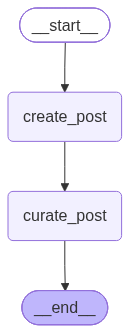

In [14]:
from IPython.display import display

display(pydantic_graph)

In [15]:
result = pydantic_graph.invoke(
    graph_schema(
        topic="The beauty of nature",
        post="",
        curated_post="",
    )
)

result

{'topic': 'The beauty of nature',
 'post': "**The Beauty of Nature: A Celebration of Our Planet's Wonders**\n\nNature is a masterpiece that unfolds before our eyes, a canvas painted with vibrant colors, intricate patterns, and breathtaking landscapes. From the majestic mountains that touch the sky to the serene lakes that mirror the heavens, the beauty of nature is a reminder of the world’s incredible diversity and resilience.\n\n**1. The Symphony of Colors:**\nEvery season brings a unique palette. In spring, blossoms burst forth in a riot of colors, while summer offers lush greens and vibrant wildflowers. Autumn transforms the landscape into a tapestry of reds, oranges, and yellows, and winter blankets the earth in pure white. Each hue tells a story, inviting us to pause and appreciate the fleeting moments of beauty.\n\n**2. The Majesty of Landscapes:**\nNature’s grandeur is evident in its landscapes. The towering peaks of the Himalayas, the vastness of the Grand Canyon, and the tranq